In [1]:
## perform some quick eda of other datasets to use

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
## dataset extraction 

url = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"  # 2023/24 EPL season
df = pd.read_csv(url)
df.to_csv("..\data\EPL_2324.csv", index=False)
len(df.columns)
# a lot of columns - focus on a few but response first

106

<Axes: xlabel='goal_diff', ylabel='Count'>

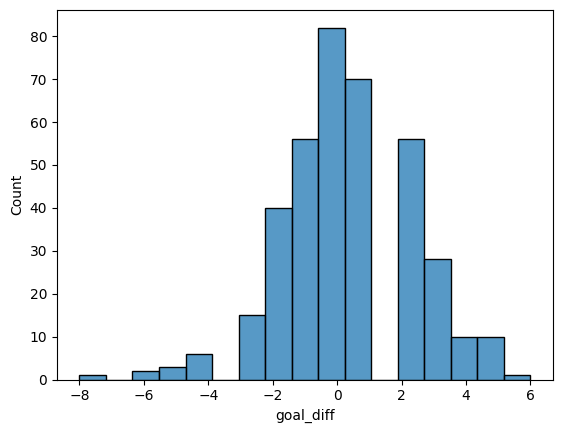

In [5]:
# Response = goal difference
df['goal_diff'] = df['FTHG'] - df['FTAG']
sns.histplot(df['goal_diff'])
# looks fairly gaussian

In [ ]:
## inputs - theres a lot so will breakdown key ones per cell

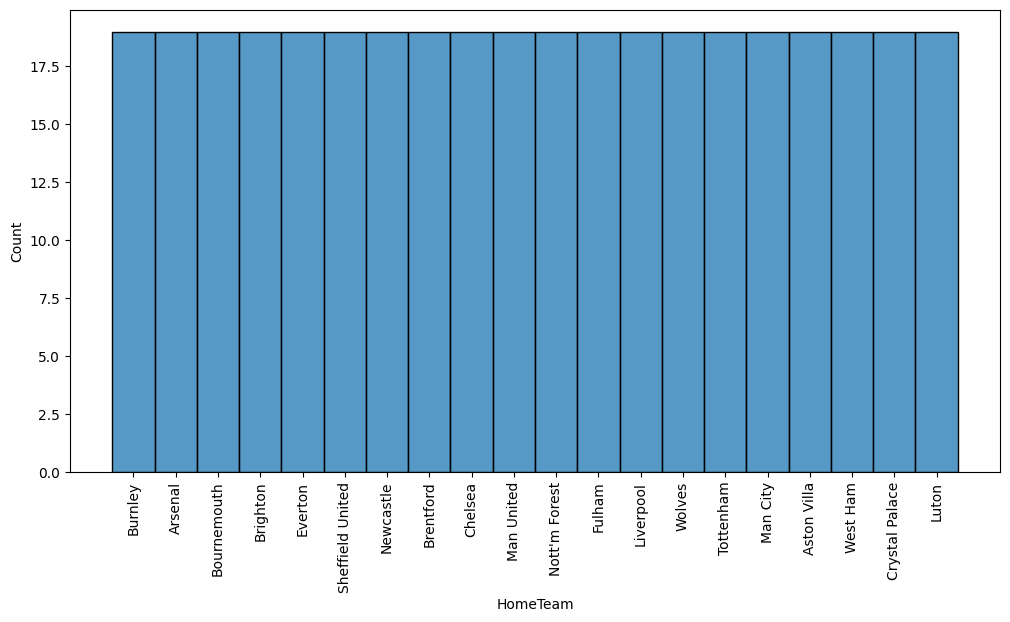

In [45]:
## mixed effects - team as random effect
plt.figure(figsize=(12, 6))
sns.histplot(df['HomeTeam'])
plt.xticks(rotation=90);

In [ ]:
## continous inputs

# gone for  a total of home + away for simplicity

<Axes: xlabel='total_shots', ylabel='goal_diff'>

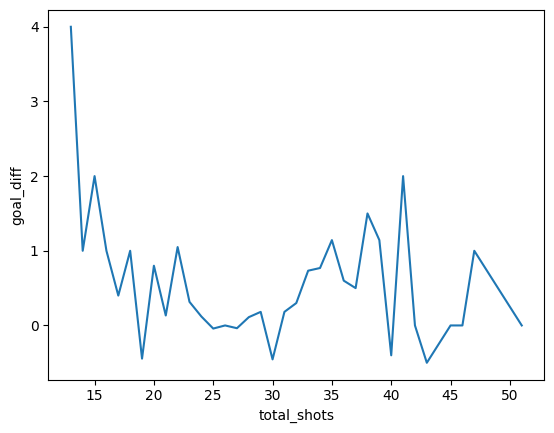

In [ ]:
# total shots
df['total_shots'] = df['HS'] + df['AS']
sns.lineplot(x='total_shots', y='goal_diff', data=df, errorbar=None)
# interesting - quickly decreases but plateaus at 20

<Axes: xlabel='total_shots_on_target', ylabel='goal_diff'>

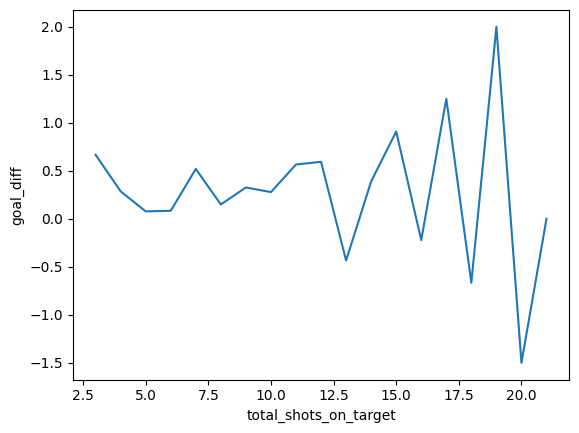

In [ ]:
# total shots on target
df['total_shots_on_target'] = df['HST'] + df['AST']
sns.lineplot(x='total_shots_on_target', y='goal_diff', data=df, errorbar=None)
# interestingly different to total shots, far more random but more extreme values as higher shots on target

<Axes: xlabel='total_fouls', ylabel='goal_diff'>

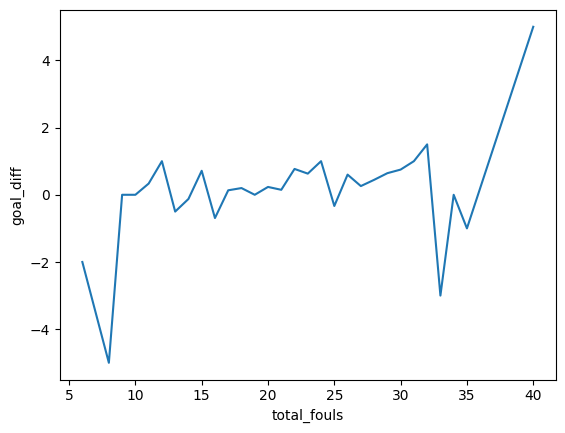

In [ ]:
# total fouls committed
df['total_fouls'] = df['HF'] + df['AF']
sns.lineplot(x='total_fouls', y='goal_diff', data=df, errorbar=None)
# increase then plateua then increase - non linear


<Axes: xlabel='total_corners', ylabel='goal_diff'>

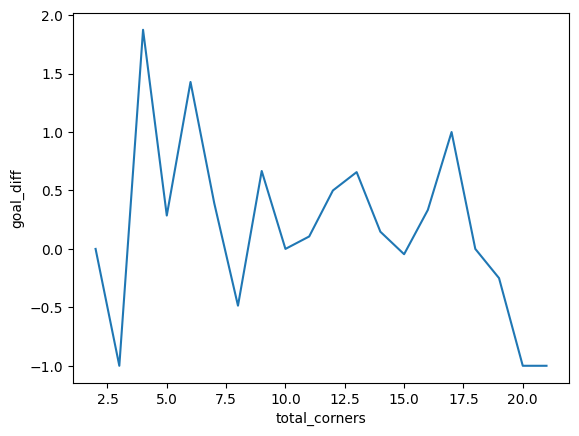

In [ ]:
#total corners
df['total_corners'] = df['HC'] + df['AC']   
sns.lineplot(x='total_corners', y='goal_diff', data=df, errorbar=None)
# not much of a trend, arguably a slight increase then plateua then decrease

<Axes: xlabel='total_yellow_cards', ylabel='goal_diff'>

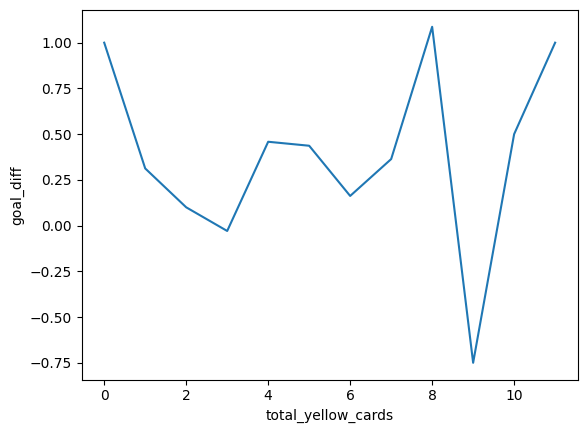

In [ ]:
# total yellow cards
df['total_yellow_cards'] = df['HY'] + df['AY']
sns.lineplot(x='total_yellow_cards', y='goal_diff', data=df, errorbar=None)
# no trend

<Axes: xlabel='total_red_cards', ylabel='goal_diff'>

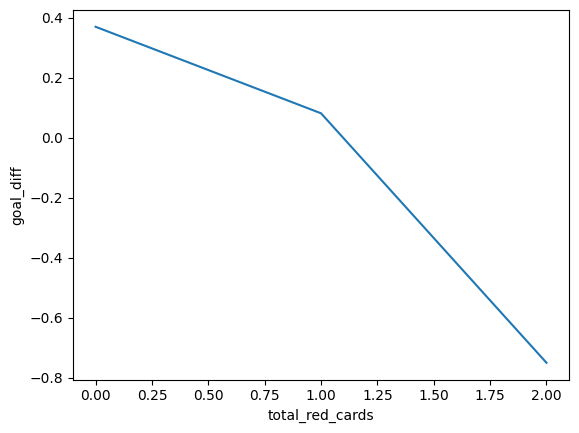

In [ ]:
# total red cards
df['total_red_cards'] = df['HR'] + df['AR']
sns.lineplot(x='total_red_cards', y='goal_diff', data=df, errorbar=None)
#strong negative correlation

In [ ]:
# betting odds
# theres a lot of columns here so we have two options:
## take an average
## do investigation find the best predictor
## test each bookie in the final model 


In [7]:
# convert to implied probabilities so the event has % chance of happening according to the bookie
def implied_prob(col,df =df):
        df[col + '_prob'] = 1 / df[col]
        

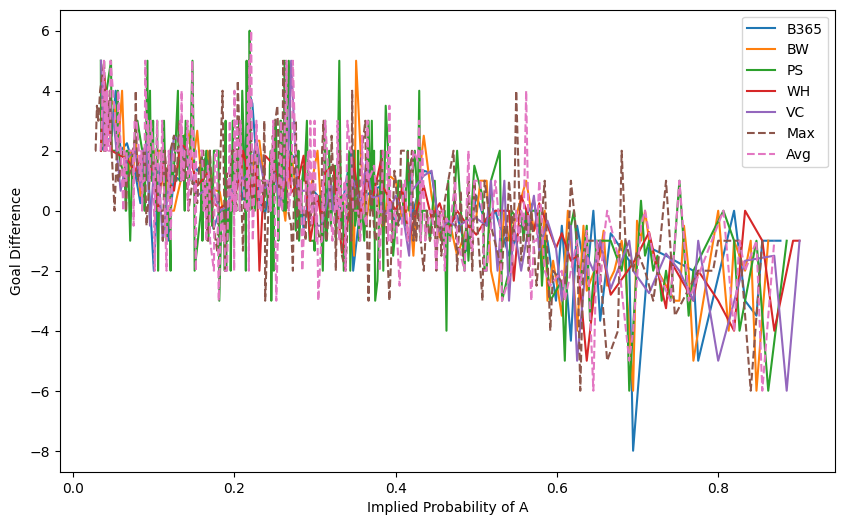

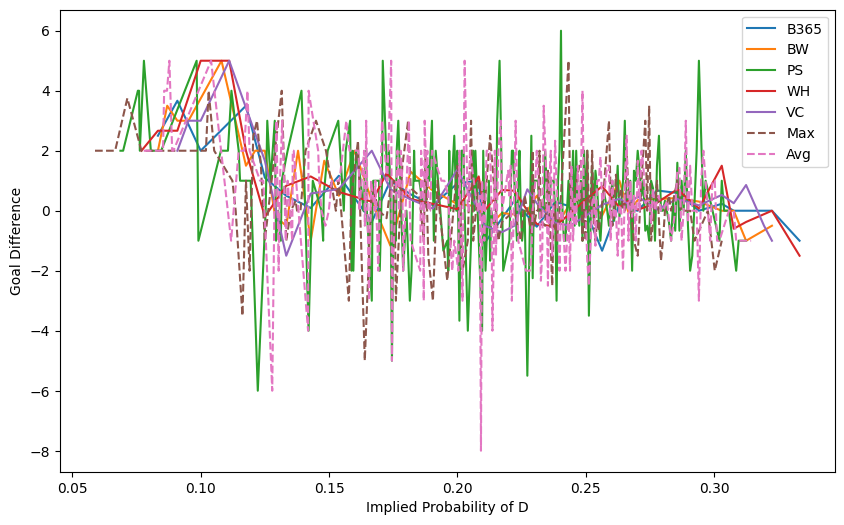

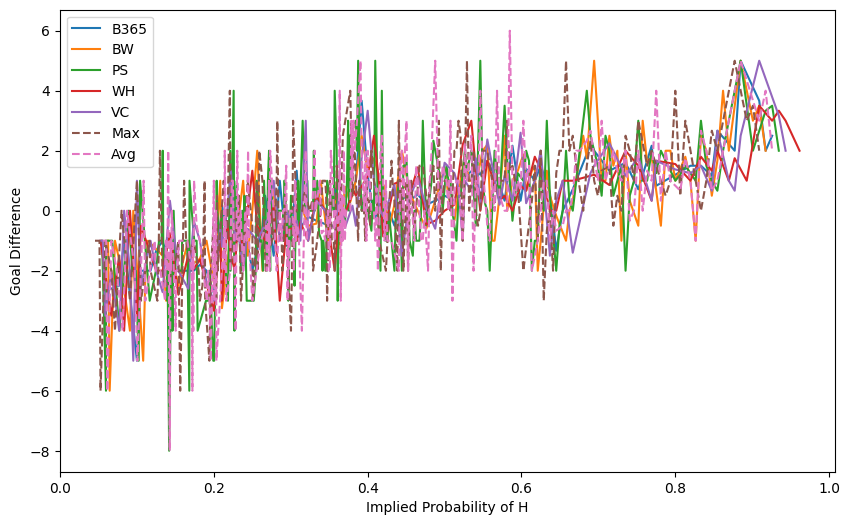

In [8]:
types = ['A', 'D', 'H']
# drop IWH as has a lot of nans
bookies  = ['B365', 'BW', 'PS', 'WH', 'VC']
for type in types:
    plt.figure(figsize=(10, 6))
    plt.xlabel(f'Implied Probability of {type}')
    plt.ylabel('Goal Difference')
    for bookie in bookies:
        implied_prob(f'{bookie}{type}')
        sns.lineplot(x=f'{bookie}{type}_prob', y='goal_diff', data=df, errorbar=None, label=bookie)
    # plot max and avg odds
    implied_prob('Max' + type)
    sns.lineplot(x=f'Max{type}_prob', y='goal_diff', data=df, errorbar=None, label='Max', linestyle='--')
    implied_prob('Avg' + type)  
    sns.lineplot(x=f'Avg{type}_prob', y='goal_diff', data=df, errorbar=None, label='Avg',linestyle='--' )
    plt.legend()
    # Looks like away and home odds show a trend, but draw does not. no clear best bookie - lets try further analysis

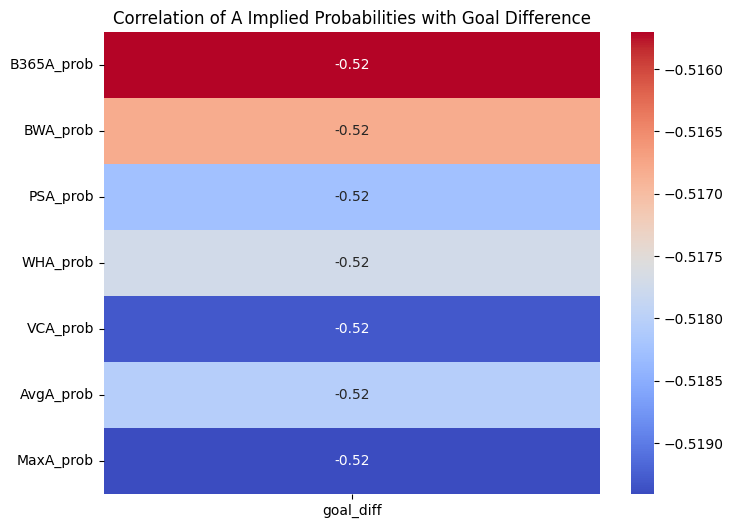

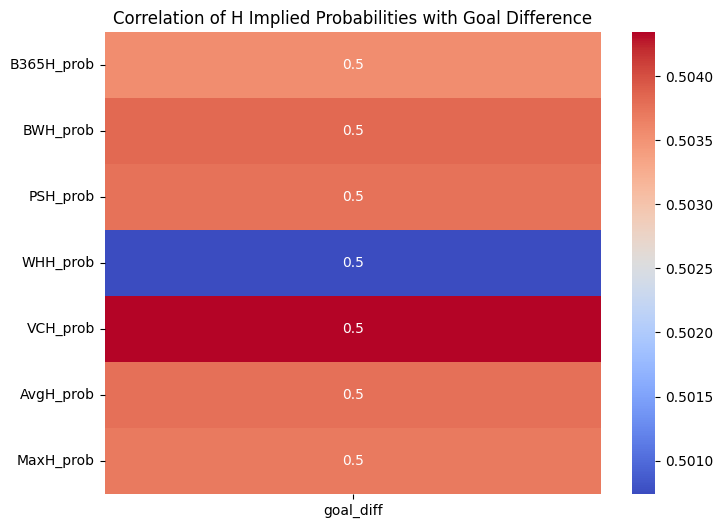

In [9]:
for type in types:
    if type == 'H' or type == 'A':
        df_corr = df[[f'{bookie}{type}_prob' for bookie in bookies] + [f'Avg{type}_prob', f'Max{type}_prob'] + ['goal_diff']]
        corrs = df_corr.corr()
        corr_goal_diff = corrs[['goal_diff']].drop('goal_diff')  # Drop self-correlation
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_goal_diff, annot=True, cmap='coolwarm')
        plt.title(f'Correlation of {type} Implied Probabilities with Goal Difference')
# not tellinng anything

In [ ]:
# looks to have a fiarly linear relationship - build a simple model to see which has best predictive power
# need full data so drop any rows with nans - will have to do this for modelling anyway
for type in types:
    if type == 'H' or type == 'A':
        df_model = df[[f'{bookie}{type}_prob' for bookie in bookies] + [f'Avg{type}_prob', f'Max{type}_prob'] + ['goal_diff']]
        df_model = df.dropna()
        #build model
        y = df_model['goal_diff']
        X = df_model[[f'{bookie}{type}_prob' for bookie in bookies] + [f'Avg{type}_prob', f'Max{type}_prob']]
        r2_results = {}
        for col in X.columns:  
            X_col = X[[col]]
            model = LinearRegression().fit(X_col, y)
            y_pred = model.predict(X_col)
            r2_results[col] = r2_score(y, y_pred)
            r2_results = dict(sorted(r2_results.items(), key=lambda item: item[1], reverse=True))
        print(pd.DataFrame(r2_results, index=[type]))
        
        print("\n")
        
# conclusion - R² tells you how much of the variance in the outcome  is explained by the predictor -  ie its predictive power so higher = better
# limited differences will have to plug into final model and see which works best

   PSA_prob  AvgA_prob  MaxA_prob  VCA_prob  BWA_prob  WHA_prob  B365A_prob
A  0.193509   0.192153   0.191809  0.191276   0.19051  0.190312    0.188324


   VCH_prob  MaxH_prob  PSH_prob  AvgH_prob  BWH_prob  WHH_prob  B365H_prob
H  0.189425   0.189054  0.188959   0.187922   0.18706   0.18551    0.185215




# categorical inputs

<Axes: xlabel='month', ylabel='goal_diff'>

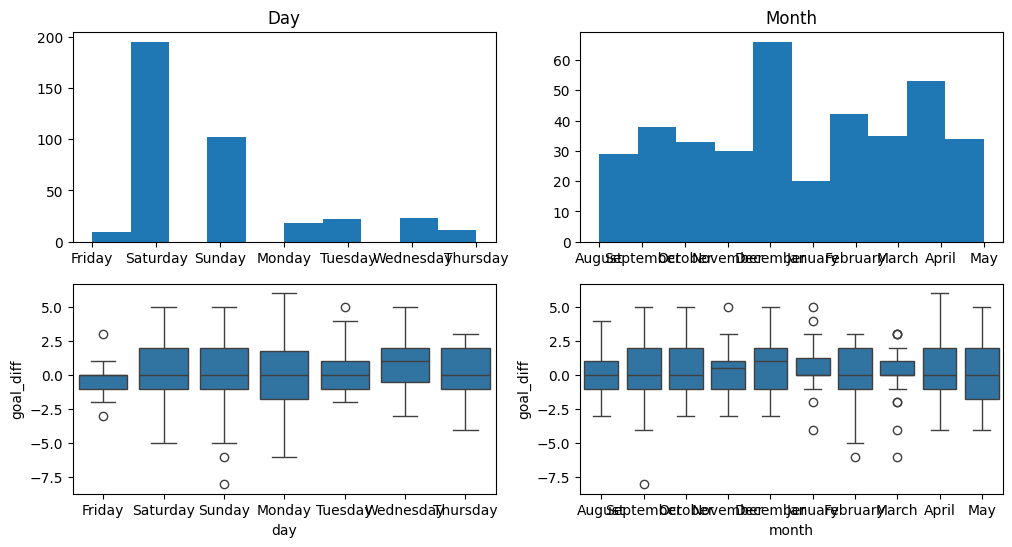

In [ ]:
df['date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Extract day and month
df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
# Plot histograms and boxplots
fig, ax = plt.subplots(2,2, figsize=(12, 6))
ax[0,0].hist(df['day'])
ax[0,0].set_title('Day')
ax[0,1].hist(df['month'])
ax[0,1].set_title('Month')
sns.boxplot(x='day', y='goal_diff', data=df, ax=ax[1,0])
sns.boxplot(x='month', y='goal_diff', data=df, ax=ax[1,1])
# no trends as expected but far less data on weekdays and none over summer months
# for months treat as categorical - updated code to be month name


In [8]:
df['Date']

0      11/08/2023
1      12/08/2023
2      12/08/2023
3      12/08/2023
4      12/08/2023
          ...    
375    19/05/2024
376    19/05/2024
377    19/05/2024
378    19/05/2024
379    19/05/2024
Name: Date, Length: 380, dtype: object

<Axes: xlabel='Is_Weekend', ylabel='goal_diff'>

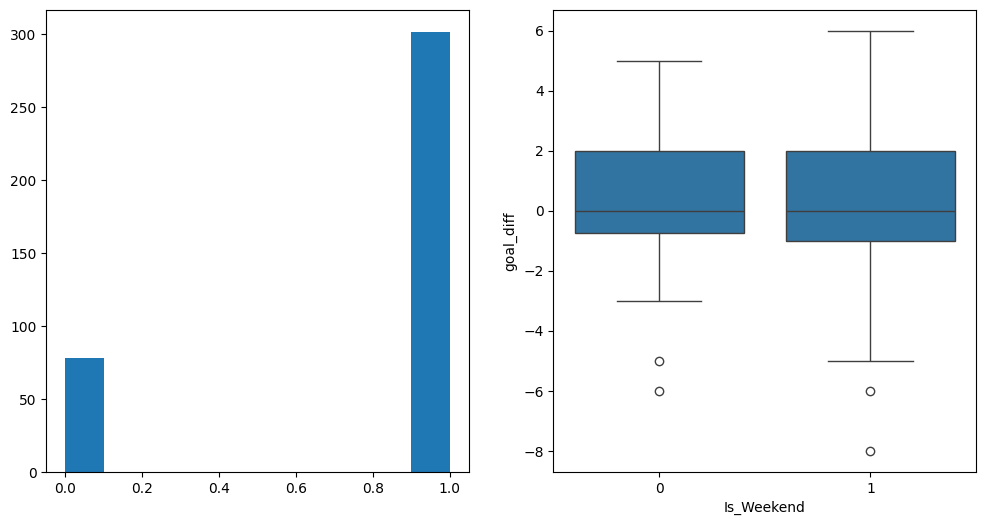

In [14]:
#due to daataset size inbalances consdier making weekdays and weekends binary variables
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Is_Weekend'] = df['Date'].dt.day.apply(lambda x: 1 if x > 5 else 0)
# Plot histograms and boxplots
fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].hist(df['Is_Weekend'])
sns.boxplot(x='Is_Weekend', y='goal_diff', data=df, ax=ax[1])


<Axes: xlabel='FTR', ylabel='goal_diff'>

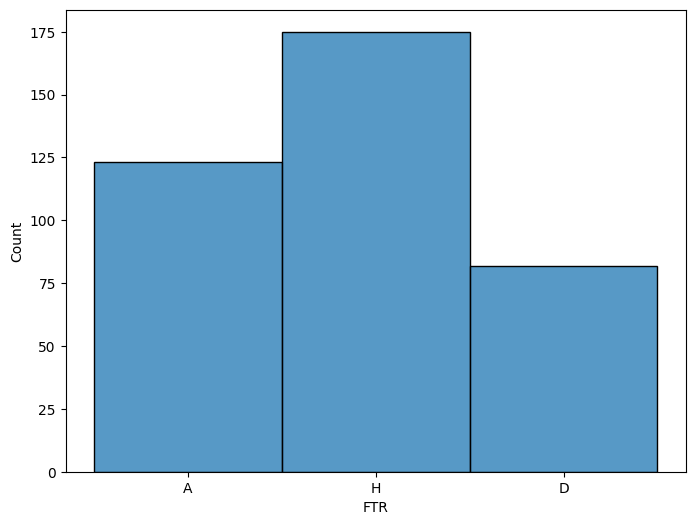

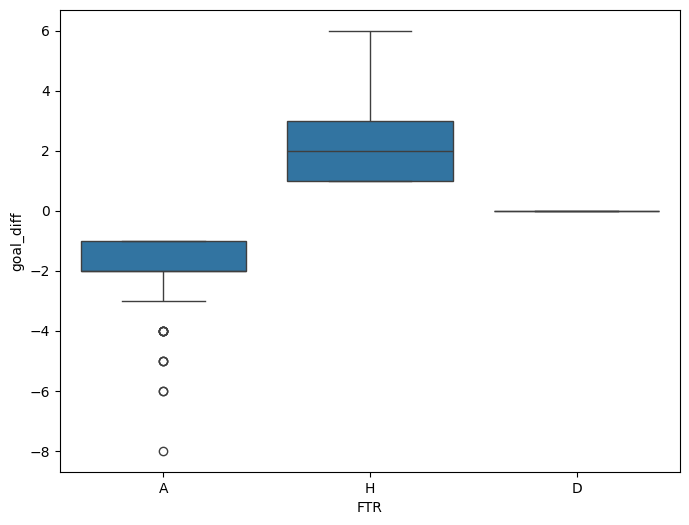

In [ ]:
# full time result
plt.figure(figsize=(8, 6))
sns.histplot(x='FTR', data=df) 
plt.figure(figsize=(8, 6))
sns.boxplot(y='goal_diff', x='FTR', data=df)
# of course draw makes sense as no spread - will provide useful baseline

<Axes: xlabel='Referee', ylabel='goal_diff'>

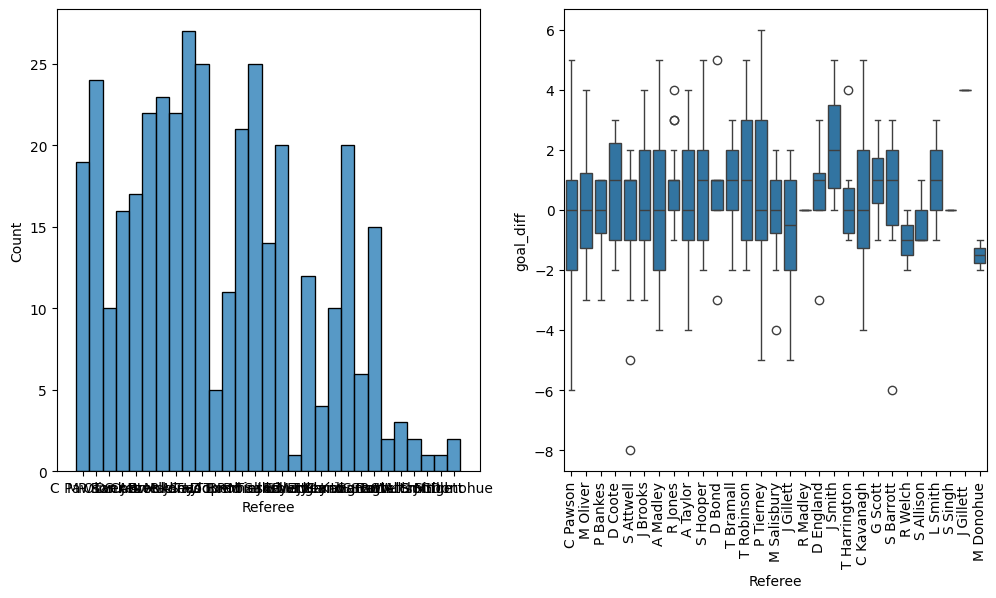

In [ ]:
# referee
fig, ax = plt.subplots(1,2,figsize=(12, 6))
plt.xticks(rotation=90);
sns.histplot(df['Referee'], ax=ax[0])
sns.boxplot(x='Referee', y='goal_diff', data=df, ax=ax[1])
# some referees have far more games - will need to check crossover to assess data sparsity 


In [21]:
### DATA SPARSITY

In [ ]:
## for the model to be robust and reliable we need to ensure that there is sufficient data for each level of inputs (teams and referees).
# columns to check - results (A, D, H) - should be fine as balanced, HomeTeam, AwayTeam
# referees - some have far more games so will need to check crossover with teams to ensure no data sparsity issues
# dates - inbalances seen
# even if some factors have balanced levels they may not crossover enough - eg a referee may only officiate a few teams

In [15]:
### SAVE DATASET FOR MODELLING IN r 

In [ ]:
# drop unused columns
cols_drop = 